In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
excel_file = pd.ExcelFile("./Data/cleaned_data.xlsx")
sheet_names = excel_file.sheet_names  # List all sheet names
print("Available sheets:", sheet_names)

# Read the second sheet
df = pd.read_excel(excel_file, sheet_name=sheet_names[1])

Available sheets: ['Raw Data', 'Cleaned Data']


In [4]:
df.head()

,StartDate,EndDate,Progress,Duration,Finished,Drop,RecordedDate,FamiliarHP,FamiliarA51P,FamiliarDHP,...,Like_Trad,SocResponse,TradResponse,Promo,PersonalInfo,MultipleOffer,MinDiscount,MostPay,Year,Gender
0,2025-05-01 08:11:29,2025-05-01 08:14:05,100,156,1,1,2025-05-01 08:14:05.915,0,0,0,...,2.0,2.0,2.0,1.0,NaN,NaN,50.0,NaN,3.0,1.0
1,2025-05-01 09:02:14,2025-05-01 09:03:51,100,96,1,1,2025-05-01 09:03:51.808,0,0,0,...,1.0,2.0,3.0,2.0,NaN,NaN,23.0,NaN,3.0,1.0
2,2025-05-01 14:13:26,2025-05-01 14:15:30,100,124,1,1,2025-05-01 14:15:30.946,0,0,0,...,2.0,2.0,4.0,1.0,NaN,NaN,31.0,NaN,3.0,1.0
3,2025-05-01 14:19:37,2025-05-01 14:21:36,100,118,1,1,2025-05-01 14:21:36.748,0,0,0,...,1.0,2.0,2.0,2.0,NaN,NaN,91.0,NaN,3.0,1.0
4,2025-05-07 23:05:30,2025-05-07 23:06:56,100,86,1,1,2025-05-07 23:06:56.906,0,0,0,...,3.0,1.0,2.0,1.0,NaN,NaN,40.0,NaN,2.0,1.0


In [5]:
valid = df[df['Drop']==0]
valid.head()

,StartDate,EndDate,Progress,Duration,Finished,Drop,RecordedDate,FamiliarHP,FamiliarA51P,FamiliarDHP,...,Like_Trad,SocResponse,TradResponse,Promo,PersonalInfo,MultipleOffer,MinDiscount,MostPay,Year,Gender
32,2025-05-12 11:53:50,2025-05-12 11:55:21,100,90,1,0,2025-05-12 11:55:21.734,1,1,0,...,3.0,2.0,4.0,1.0,4.0,5.0,20.0,72.0,3.0,2.0
33,2025-05-12 11:57:38,2025-05-12 11:59:48,100,129,1,0,2025-05-12 11:59:48.551,1,0,0,...,2.0,2.0,4.0,1.0,4.0,5.0,25.0,17.0,3.0,2.0
34,2025-05-12 11:57:33,2025-05-12 11:59:52,100,138,1,0,2025-05-12 11:59:52.414,1,0,0,...,4.0,2.0,2.0,1.0,4.0,6.0,20.0,50.0,3.0,2.0
35,2025-05-12 12:00:21,2025-05-12 12:01:46,100,84,1,0,2025-05-12 12:01:46.560,1,0,0,...,3.0,2.0,4.0,1.0,4.0,6.0,50.0,50.0,3.0,2.0
36,2025-05-12 12:00:59,2025-05-12 12:02:19,100,79,1,0,2025-05-12 12:02:20.108,0,0,0,...,2.0,2.0,4.0,1.0,2.0,6.0,40.0,29.0,2.0,1.0


In [6]:
valid.describe().iloc[:, 6:]

,RecordedDate,FamiliarHP,FamiliarA51P,FamiliarDHP,Like_WoM,Like_Soc,Like_Trad,SocResponse,TradResponse,Promo,PersonalInfo,MultipleOffer,MinDiscount,MostPay,Year,Gender
count,54,54.000000,54.000000,54.000000,53.000000,52.000000,52.000000,53.000000,53.000000,54.000000,54.000000,54.000000,54.000000,53.000000,54.000000,54.000000
mean,2025-05-14 04:40:42.359943936,0.537037,0.240741,0.055556,3.679245,3.307692,2.192308,2.773585,2.886792,1.962963,3.462963,5.129630,46.370370,48.452830,2.666667,1.240741
min,2025-05-12 11:55:21.734000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,15.000000,1.000000,1.000000,1.000000
25%,2025-05-12 12:40:15.291249920,0.000000,0.000000,0.000000,3.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,5.000000,25.000000,39.000000,2.000000,1.000000
50%,2025-05-12 20:27:27.180999936,1.000000,0.000000,0.000000,4.000000,3.500000,2.000000,2.000000,2.000000,1.500000,4.000000,5.000000,40.500000,50.000000,3.000000,1.000000
75%,2025-05-14 19:19:01.889750016,1.000000,0.000000,0.000000,5.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,6.000000,63.750000,60.000000,3.000000,1.000000
max,2025-05-18 23:05:50.784000,1.000000,1.000000,1.000000,5.000000,5.000000,4.000000,5.000000,4.000000,5.000000,5.000000,7.000000,100.000000,100.000000,5.000000,3.000000
std,NaN,0.503308,0.431548,0.231212,1.438129,1.180536,0.908316,1.234777,1.012620,1.164943,1.269571,1.480009,22.955491,21.913787,1.063990,0.473254


In [7]:
valid['FamiliarA51P'].value_counts(), valid['FamiliarHP'].value_counts(), valid['FamiliarDHP'].value_counts()

(FamiliarA51P
 0    41
 1    13
 Name: count, dtype: int64,
 FamiliarHP
 1    29
 0    25
 Name: count, dtype: int64,
 FamiliarDHP
 0    51
 1     3
 Name: count, dtype: int64)

In [8]:
valid['Year'].value_counts(), valid['Gender'].value_counts()

(Year
 3.0    21
 2.0    11
 4.0    11
 1.0    10
 5.0     1
 Name: count, dtype: int64,
 Gender
 1.0    42
 2.0    11
 3.0     1
 Name: count, dtype: int64)

In [9]:
fresh = valid[valid['Year']==1].iloc[:, 6:]
fresh.describe()

,RecordedDate,FamiliarHP,FamiliarA51P,FamiliarDHP,Like_WoM,Like_Soc,Like_Trad,SocResponse,TradResponse,Promo,PersonalInfo,MultipleOffer,MinDiscount,MostPay,Year,Gender
count,10,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.00000,10.000000,10.000000,10.000000,10.000000,10.0,10.0
mean,2025-05-14 08:06:02.683399936,0.400000,0.300000,0.200000,3.300000,3.600000,2.300000,3.400000,2.400000,2.10000,3.600000,5.400000,49.000000,51.500000,1.0,1.0
min,2025-05-12 12:30:39.003000,0.000000,0.000000,0.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.00000,2.000000,4.000000,20.000000,28.000000,1.0,1.0
25%,2025-05-13 01:04:28.225999872,0.000000,0.000000,0.000000,2.250000,3.000000,1.000000,2.000000,2.000000,1.00000,2.250000,5.000000,28.750000,46.250000,1.0,1.0
50%,2025-05-14 11:48:22.378000128,0.000000,0.000000,0.000000,4.000000,4.000000,2.000000,3.000000,2.000000,2.00000,4.000000,5.000000,49.500000,50.000000,1.0,1.0
75%,2025-05-14 12:14:50.888250112,1.000000,0.750000,0.000000,4.000000,4.000000,3.750000,5.000000,2.750000,2.00000,4.750000,6.000000,69.500000,50.750000,1.0,1.0
max,2025-05-18 18:24:07.604000,1.000000,1.000000,1.000000,5.000000,5.000000,4.000000,5.000000,4.000000,5.00000,5.000000,7.000000,75.000000,100.000000,1.0,1.0
std,NaN,0.516398,0.483046,0.421637,1.494434,0.843274,1.337494,1.505545,0.966092,1.37032,1.264911,0.843274,22.191089,18.596595,0.0,0.0


In [10]:
soph = valid[valid['Year']==2].iloc[:, 6:]
soph.describe()

,RecordedDate,FamiliarHP,FamiliarA51P,FamiliarDHP,Like_WoM,Like_Soc,Like_Trad,SocResponse,TradResponse,Promo,PersonalInfo,MultipleOffer,MinDiscount,MostPay,Year,Gender
count,11,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.0,11.000000
mean,2025-05-14 11:21:45.060909056,0.272727,0.090909,0.090909,3.363636,2.363636,1.909091,2.454545,3.272727,2.454545,2.909091,4.454545,50.454545,39.909091,2.0,1.090909
min,2025-05-12 12:02:20.108000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,20.000000,4.000000,2.0,1.000000
25%,2025-05-12 13:00:59.506999808,0.000000,0.000000,0.000000,2.000000,2.000000,1.500000,2.000000,2.000000,1.500000,2.000000,4.000000,32.500000,32.000000,2.0,1.000000
50%,2025-05-12 21:37:25.116000,0.000000,0.000000,0.000000,3.000000,2.000000,2.000000,2.000000,4.000000,3.000000,2.000000,4.000000,50.000000,40.000000,2.0,1.000000
75%,2025-05-15 15:12:43.625999872,0.500000,0.000000,0.000000,5.000000,3.000000,2.000000,2.500000,4.000000,3.000000,4.000000,5.500000,67.500000,50.000000,2.0,1.000000
max,2025-05-18 20:34:37.510000,1.000000,1.000000,1.000000,5.000000,5.000000,3.000000,5.000000,4.000000,4.000000,5.000000,6.000000,90.000000,65.000000,2.0,2.000000
std,NaN,0.467099,0.301511,0.301511,1.689540,1.120065,0.700649,0.934199,1.009050,1.035725,1.513575,1.439697,23.393861,17.980292,0.0,0.301511


In [11]:
jun = valid[valid['Year']==3].iloc[:, 6:]
jun.describe()

,RecordedDate,FamiliarHP,FamiliarA51P,FamiliarDHP,Like_WoM,Like_Soc,Like_Trad,SocResponse,TradResponse,Promo,PersonalInfo,MultipleOffer,MinDiscount,MostPay,Year,Gender
count,21,21.000000,21.000000,21.0,20.000000,19.000000,19.000000,20.000000,20.000000,21.000000,21.000000,21.00000,21.000000,21.000000,21.0,21.000000
mean,2025-05-13 22:20:18.190619136,0.714286,0.285714,0.0,4.050000,3.736842,2.473684,2.400000,3.150000,1.761905,3.857143,5.52381,43.095238,49.000000,3.0,1.476190
min,2025-05-12 11:55:21.734000,0.000000,0.000000,0.0,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.00000,20.000000,1.000000,3.0,1.000000
25%,2025-05-12 12:26:40.728999936,0.000000,0.000000,0.0,4.000000,3.000000,2.000000,2.000000,2.000000,1.000000,4.000000,5.00000,25.000000,39.000000,3.0,1.000000
50%,2025-05-12 13:14:06.072000,1.000000,0.000000,0.0,4.000000,4.000000,2.000000,2.000000,4.000000,1.000000,4.000000,6.00000,40.000000,50.000000,3.0,1.000000
75%,2025-05-14 10:45:40.335000064,1.000000,1.000000,0.0,5.000000,4.500000,3.000000,2.000000,4.000000,2.000000,4.000000,6.00000,60.000000,60.000000,3.0,2.000000
max,2025-05-18 23:05:50.784000,1.000000,1.000000,0.0,5.000000,5.000000,4.000000,5.000000,4.000000,5.000000,5.000000,7.00000,100.000000,100.000000,3.0,3.000000
std,NaN,0.462910,0.462910,0.0,1.050063,1.147079,0.696692,0.940325,0.988087,1.261141,0.910259,1.40068,22.311219,25.948025,0.0,0.601585


In [12]:
sen = valid[valid['Year']==4].iloc[:, 6:]
sen.describe()

,RecordedDate,FamiliarHP,FamiliarA51P,FamiliarDHP,Like_WoM,Like_Soc,Like_Trad,SocResponse,TradResponse,Promo,PersonalInfo,MultipleOffer,MinDiscount,MostPay,Year,Gender
count,11,11.000000,11.000000,11.0,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,10.000000,11.0,11.000000
mean,2025-05-14 09:51:10.042727424,0.636364,0.181818,0.0,3.636364,3.181818,1.909091,3.272727,2.545455,1.636364,3.363636,4.818182,48.545455,51.500000,4.0,1.181818
min,2025-05-12 12:24:34.602000,0.000000,0.000000,0.0,1.000000,1.000000,1.000000,2.000000,2.000000,1.000000,1.000000,1.000000,15.000000,8.000000,4.0,1.000000
25%,2025-05-12 15:52:52.236999936,0.000000,0.000000,0.0,2.000000,2.500000,1.000000,2.000000,2.000000,1.000000,3.000000,4.500000,30.000000,41.250000,4.0,1.000000
50%,2025-05-12 19:45:41.902000128,1.000000,0.000000,0.0,5.000000,3.000000,2.000000,2.000000,2.000000,1.000000,4.000000,6.000000,40.000000,50.000000,4.0,1.000000
75%,2025-05-15 16:00:53.730500096,1.000000,0.000000,0.0,5.000000,4.000000,2.000000,5.000000,3.000000,2.000000,4.000000,6.000000,65.000000,68.750000,4.0,1.000000
max,2025-05-18 18:05:37.807000,1.000000,1.000000,0.0,5.000000,5.000000,4.000000,5.000000,4.000000,3.000000,5.000000,6.000000,100.000000,75.000000,4.0,2.000000
std,NaN,0.504525,0.404520,0.0,1.804036,1.167748,0.943880,1.489356,0.934199,0.809040,1.361817,1.990888,26.158607,20.277245,0.0,0.404520


In [13]:
grad = valid[valid['Year']==5].iloc[:, 6:]
grad.describe()

,RecordedDate,FamiliarHP,FamiliarA51P,FamiliarDHP,Like_WoM,Like_Soc,Like_Trad,SocResponse,TradResponse,Promo,PersonalInfo,MultipleOffer,MinDiscount,MostPay,Year,Gender
count,1,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
mean,2025-05-12 21:09:12.460000,0.0,1.0,0.0,4.0,4.0,2.0,2.0,2.0,3.0,1.0,5.0,20.0,70.0,5.0,1.0
min,2025-05-12 21:09:12.460000,0.0,1.0,0.0,4.0,4.0,2.0,2.0,2.0,3.0,1.0,5.0,20.0,70.0,5.0,1.0
25%,2025-05-12 21:09:12.460000,0.0,1.0,0.0,4.0,4.0,2.0,2.0,2.0,3.0,1.0,5.0,20.0,70.0,5.0,1.0
50%,2025-05-12 21:09:12.460000,0.0,1.0,0.0,4.0,4.0,2.0,2.0,2.0,3.0,1.0,5.0,20.0,70.0,5.0,1.0
75%,2025-05-12 21:09:12.460000,0.0,1.0,0.0,4.0,4.0,2.0,2.0,2.0,3.0,1.0,5.0,20.0,70.0,5.0,1.0
max,2025-05-12 21:09:12.460000,0.0,1.0,0.0,4.0,4.0,2.0,2.0,2.0,3.0,1.0,5.0,20.0,70.0,5.0,1.0
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [14]:
men = valid[valid['Gender']==1].iloc[:, 6:]
men.describe()

,RecordedDate,FamiliarHP,FamiliarA51P,FamiliarDHP,Like_WoM,Like_Soc,Like_Trad,SocResponse,TradResponse,Promo,PersonalInfo,MultipleOffer,MinDiscount,MostPay,Year,Gender
count,42,42.000000,42.000000,42.000000,42.000000,41.000000,41.000000,42.000000,42.000000,42.000000,42.000000,42.000000,42.000000,41.000000,42.000000,42.0
mean,2025-05-14 08:52:24.372476416,0.476190,0.261905,0.071429,3.476190,3.170732,2.146341,2.785714,2.785714,1.904762,3.238095,5.214286,47.976190,48.731707,2.547619,1.0
min,2025-05-12 12:02:20.108000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,15.000000,1.000000,1.000000,1.0
25%,2025-05-12 13:05:36.276749824,0.000000,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000,2.000000,1.000000,2.000000,5.000000,25.000000,40.000000,2.000000,1.0
50%,2025-05-12 21:23:18.788000,0.000000,0.000000,0.000000,4.000000,3.000000,2.000000,2.000000,2.000000,1.500000,4.000000,5.500000,49.500000,50.000000,3.000000,1.0
75%,2025-05-14 19:19:01.889750016,1.000000,0.750000,0.000000,5.000000,4.000000,3.000000,3.750000,4.000000,3.000000,4.000000,6.000000,68.750000,54.000000,3.000000,1.0
max,2025-05-18 23:05:50.784000,1.000000,1.000000,1.000000,5.000000,5.000000,4.000000,5.000000,4.000000,5.000000,5.000000,7.000000,100.000000,100.000000,5.000000,1.0
std,NaN,0.505487,0.445001,0.260661,1.517991,1.222752,0.937043,1.259805,1.000871,1.100100,1.339995,1.490387,23.873128,21.826617,1.151931,0.0


In [15]:
women = valid[valid['Gender']==2].iloc[:, 6:]
women.describe()

,RecordedDate,FamiliarHP,FamiliarA51P,FamiliarDHP,Like_WoM,Like_Soc,Like_Trad,SocResponse,TradResponse,Promo,PersonalInfo,MultipleOffer,MinDiscount,MostPay,Year,Gender
count,11,11.000000,11.000000,11.0,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.000000,11.0
mean,2025-05-13 15:07:16.395000064,0.818182,0.181818,0.0,4.454545,3.818182,2.363636,2.727273,3.272727,2.181818,4.181818,5.181818,42.272727,51.090909,3.090909,2.0
min,2025-05-12 11:55:21.734000,0.000000,0.000000,0.0,3.000000,2.000000,1.000000,2.000000,2.000000,1.000000,4.000000,4.000000,20.000000,17.000000,2.000000,2.0
25%,2025-05-12 12:00:49.487000064,1.000000,0.000000,0.0,4.000000,3.500000,2.000000,2.000000,2.000000,1.000000,4.000000,4.500000,27.500000,37.000000,3.000000,2.0
50%,2025-05-12 12:41:22.569999872,1.000000,0.000000,0.0,5.000000,4.000000,2.000000,2.000000,4.000000,1.000000,4.000000,5.000000,40.000000,50.000000,3.000000,2.0
75%,2025-05-15 01:22:46.629499904,1.000000,0.000000,0.0,5.000000,4.000000,3.000000,3.000000,4.000000,3.000000,4.000000,6.000000,50.000000,72.000000,3.000000,2.0
max,2025-05-16 13:39:21.313000,1.000000,1.000000,0.0,5.000000,5.000000,4.000000,5.000000,4.000000,5.000000,5.000000,6.000000,80.000000,80.000000,4.000000,2.0
std,NaN,0.404520,0.404520,0.0,0.687552,0.873863,0.809040,1.190874,1.009050,1.470930,0.404520,0.873863,19.411805,20.491240,0.539360,0.0


In [16]:
plt.style.use('seaborn-v0_8')
average_like = valid[['Like_Soc', 'Like_WoM', 'Like_Trad']].mean()
sd_like = valid[['Like_Soc', 'Like_WoM', 'Like_Trad']].std()

In [17]:
average_like

Like_Soc     3.307692
Like_WoM     3.679245
Like_Trad    2.192308
dtype: float64

In [18]:
#print(plt.style.available)

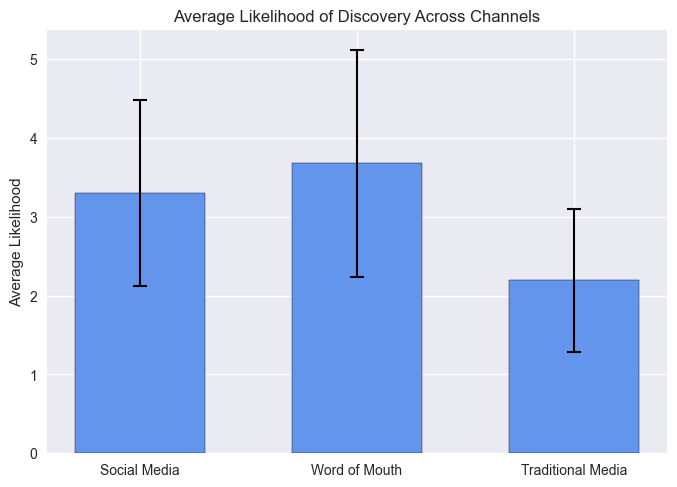

In [19]:
plt.bar([0,1,2], average_like, yerr=sd_like, width = .6, color = 'cornflowerblue', edgecolor='black',    error_kw={
        'elinewidth': 1.5,      # Line width
        'capsize': 5,           # Cap length
        'capthick': 1.5,        # Cap thickness
        'ecolor': 'black',        # Color of error bars
        'linestyle': ':'       # Dashed lines (use ':' for dotted)
    })
plt.title('Average Likelihood of Discovery Across Channels')
plt.ylabel('Average Likelihood')
plt.xticks([0,1,2], ['Social Media', 'Word of Mouth', 'Traditional Media'])
plt.savefig('AveragediscLikelihood.png')

In [20]:
social_media_counts = valid['SocResponse'].value_counts().sort_index()
social_media_counts

SocResponse
2.0    36
3.0     4
4.0     2
5.0    11
Name: count, dtype: int64

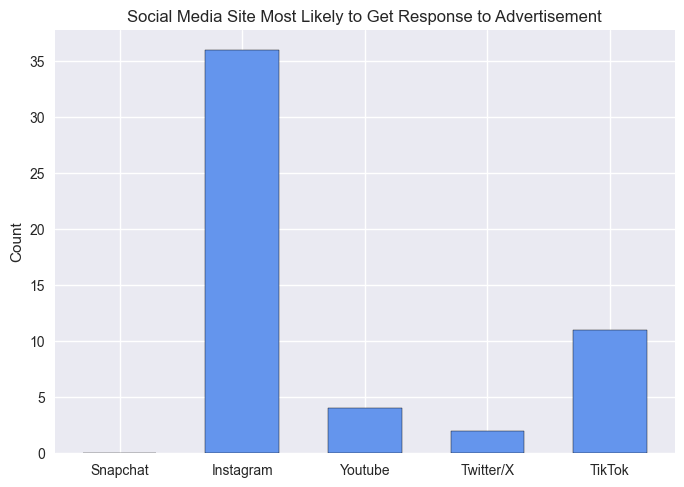

In [21]:
plt.bar(['Snapchat','Instagram','Youtube','Twitter/X','TikTok'], [0,36,4,2,11], width=.6, color='cornflowerblue', edgecolor='black')
plt.title('Social Media Site Most Likely to Get Response to Advertisement')
plt.ylabel('Count')
plt.savefig('socresponse.png')

In [22]:
tmc = valid['TradResponse'].value_counts().sort_index()
tmc

TradResponse
1.0     1
2.0    27
3.0     2
4.0    23
Name: count, dtype: int64

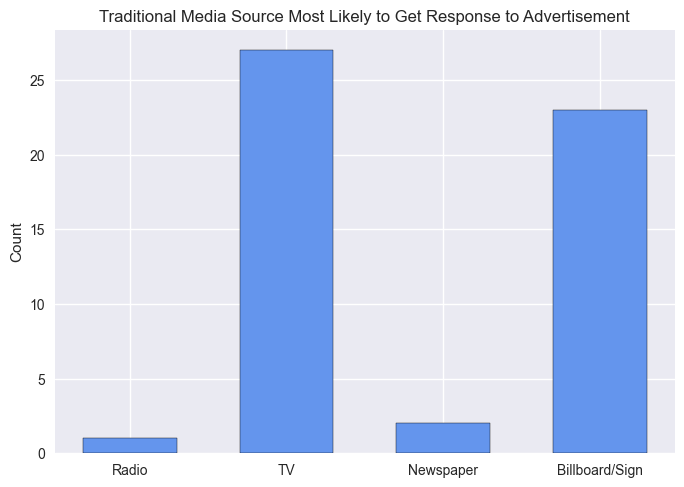

In [23]:
plt.bar(['Radio','TV','Newspaper','Billboard/Sign'], tmc.values, width=.6, color='cornflowerblue', edgecolor='black')
plt.title('Traditional Media Source Most Likely to Get Response to Advertisement')
plt.ylabel('Count')
plt.savefig('tradresponse.png')

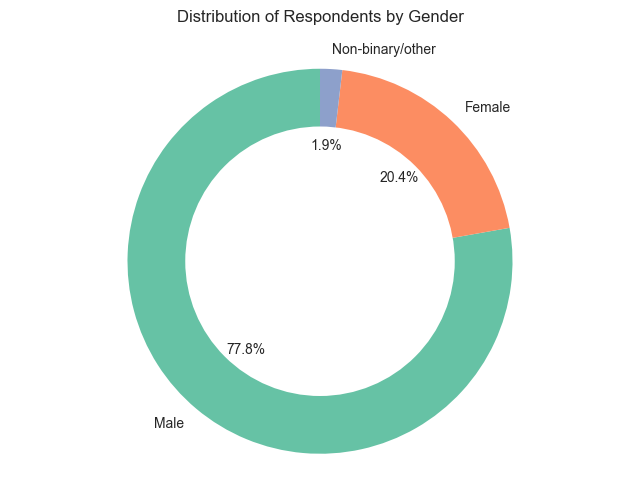

In [24]:
# Data
labels = ['Male', 'Female', 'Non-binary/other']
sizes = valid['Gender'].value_counts().sort_index().values

cmap = plt.get_cmap('Set2')
colors = cmap(range(len(labels)))

# Create pie chart
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)

# Add a white circle at the center to make it a donut
centre_circle = plt.Circle((0, 0), 0.7, color='white', fc='white', linewidth=0)
ax.add_artist(centre_circle)

# Equal aspect ratio ensures the pie is circular
ax.axis('equal')
plt.title('Distribution of Respondents by Gender', pad=20)
plt.savefig('genderdist.png')
plt.show()

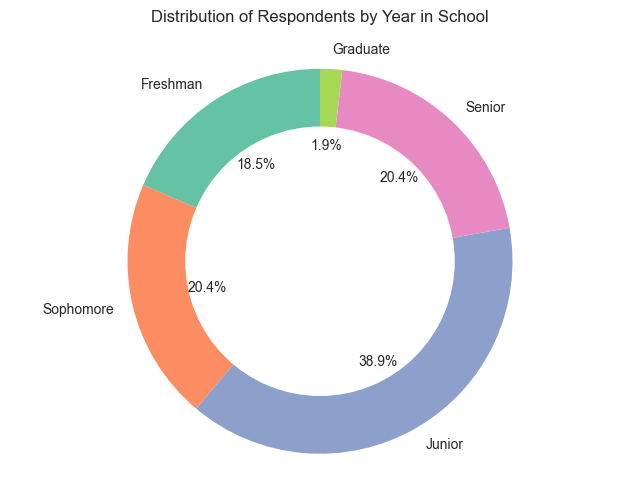

In [25]:
# Data
labels = ['Freshman', 'Sophomore', 'Junior', 'Senior', 'Graduate']
sizes = valid['Year'].value_counts().sort_index().values

cmap = plt.get_cmap('Set2')
colors = cmap(range(len(labels)))

# Create pie chart
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)

# Add a white circle at the center to make it a donut
centre_circle = plt.Circle((0, 0), 0.7, color='white', fc='white', linewidth=0)
ax.add_artist(centre_circle)

# Equal aspect ratio ensures the pie is circular
ax.axis('equal')
plt.title('Distribution of Respondents by Year in School', pad=20)
plt.savefig('yeardist.png')
plt.show()

In [26]:
promoc = valid['Promo'].value_counts().sort_index()
promoc

Promo
1.0    27
2.0    10
3.0    11
4.0     4
5.0     2
Name: count, dtype: int64

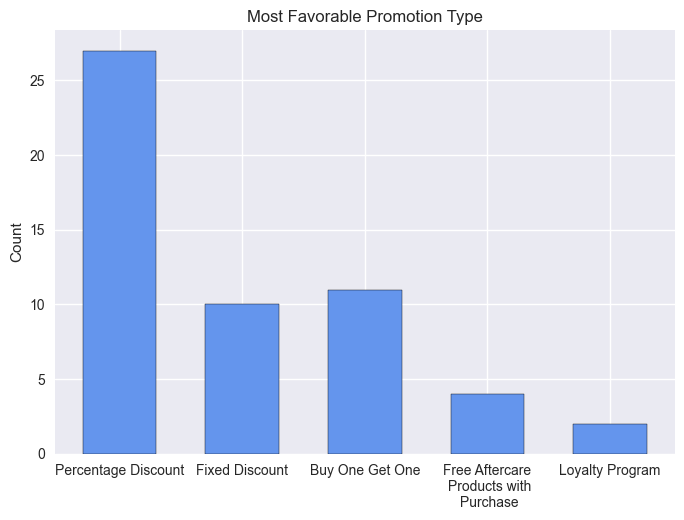

In [27]:
plt.bar(['Percentage Discount','Fixed Discount','Buy One Get One','Free Aftercare\n Products with\n Purchase','Loyalty Program'], promoc.values, width=.6, color='cornflowerblue', edgecolor='black')
plt.title('Most Favorable Promotion Type')
plt.ylabel('Count')
plt.savefig('promos.png')

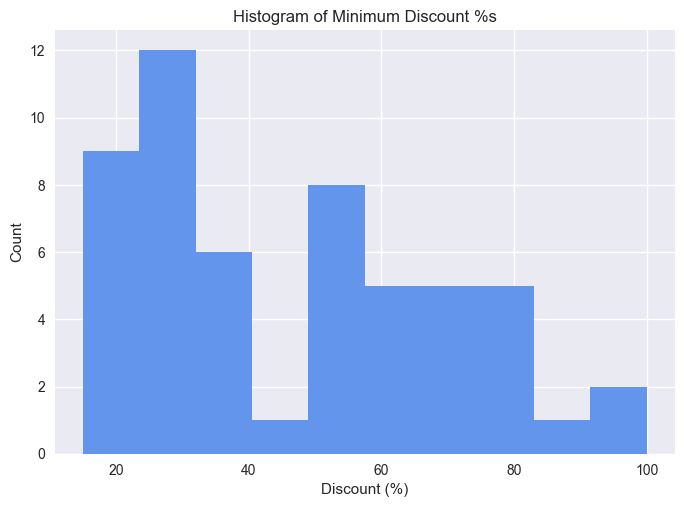

In [28]:
plt.hist(valid['MinDiscount'], color='cornflowerblue')
plt.title('Histogram of Minimum Discount %s')
plt.xlabel('Discount (%)')
plt.ylabel('Count')
plt.savefig('discounthist.png')

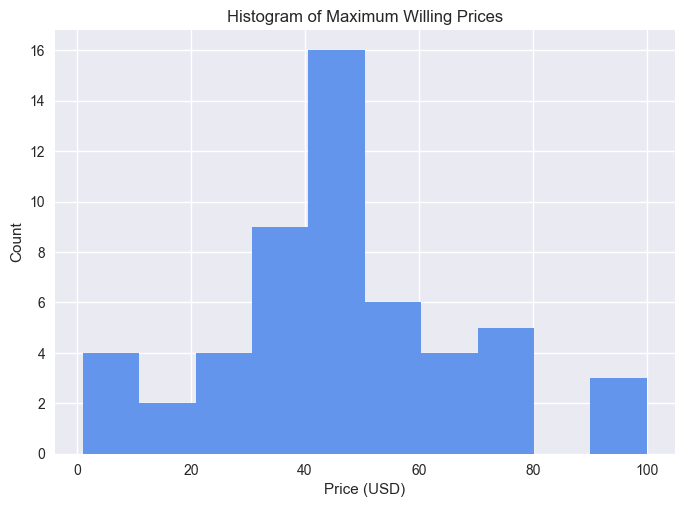

In [29]:
plt.hist(valid['MostPay'], color='cornflowerblue')
plt.title('Histogram of Maximum Willing Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Count')
plt.savefig('maxpayhist.png')

In [30]:
from scipy import stats


n = len(valid['MinDiscount'])
mean = df['MinDiscount'].mean()
std_err = df['MinDiscount'].sem()  # Standard Error of the Mean

# Use t-distribution (small samples) or z-distribution (large samples)
ci = stats.t.interval(confidence=0.95, df=n-1, loc=mean, scale=std_err)

print(f"95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})")
print(mean)

95% Confidence Interval: (41.35, 51.47)
46.411764705882355


In [31]:
n = len(valid['MostPay'])
mean = df['MostPay'].mean()
std_err = df['MostPay'].sem()  # Standard Error of the Mean

# Use t-distribution (small samples) or z-distribution (large samples)
ci = stats.t.interval(confidence=0.95, df=n-1, loc=mean, scale=std_err)

print(f"95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})")
print(mean)

95% Confidence Interval: (42.42, 54.49)
48.45283018867924


In [32]:
valid['MultipleOffer'].value_counts()

MultipleOffer
6.0    20
5.0    15
4.0     9
7.0     6
1.0     4
Name: count, dtype: int64

In [33]:
mapping = {7.0: 5.0, 6.0: 4.0, 5.0: 3.0, 4.0: 2.0}  # Add more mappings as needed

# Replace values
valid['MultipleOffer'] = df['MultipleOffer'].replace(mapping)

valid['MultipleOffer'].value_counts()

C:\Users\danie\AppData\Local\Temp\ipykernel_25388\1139912821.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['MultipleOffer'] = df['MultipleOffer'].replace(mapping)


MultipleOffer
4.0    20
3.0    15
2.0     9
5.0     6
1.0     4
Name: count, dtype: int64

In [34]:
valid['MultipleOffer'].std()

np.float64(1.106015569624394)

In [35]:
valid['MinDiscount'].describe()

count     54.000000
mean      46.370370
std       22.955491
min       15.000000
25%       25.000000
50%       40.500000
75%       63.750000
max      100.000000
Name: MinDiscount, dtype: float64

In [36]:
valid['MostPay'].describe()

count     53.000000
mean      48.452830
std       21.913787
min        1.000000
25%       39.000000
50%       50.000000
75%       60.000000
max      100.000000
Name: MostPay, dtype: float64

In [37]:
valid['MostPay'].median()

np.float64(50.0)

In [38]:
valid['Like_Trad'].describe()

count    52.000000
mean      2.192308
std       0.908316
min       1.000000
25%       2.000000
50%       2.000000
75%       3.000000
max       4.000000
Name: Like_Trad, dtype: float64

In [39]:
valid['Gender'].value_counts()

Gender
1.0    42
2.0    11
3.0     1
Name: count, dtype: int64